[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


First 5 rows:
                                      text sentiment
0       I love this product, it's amazing!  positive
1    This is the worst thing I ever bought  negative
2             Absolutely fantastic service  positive
3  I am very disappointed with the quality  negative
4         Great experience, will buy again  positive

Dataset Info:
(40, 2)
Index(['text', 'sentiment'], dtype='object')
sentiment
positive    20
negative    20
Name: count, dtype: int64

Cleaned Data Sample:
                                      text               clean_text
0       I love this product, it's amazing!        love product amaz
1    This is the worst thing I ever bought  worst thing ever bought
2             Absolutely fantastic service   absolut fantast servic
3  I am very disappointed with the quality       disappoint qualiti
4         Great experience, will buy again         great experi buy

===== NAIVE BAYES RESULTS =====
Accuracy: 0.625
              precision    recall  f1-score   support



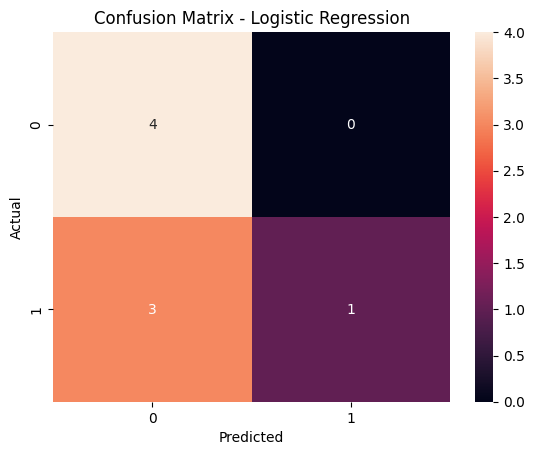


===== MODEL COMPARISON =====
Naive Bayes Accuracy: 0.625
Logistic Regression Accuracy: 0.625

===== CUSTOM TEST =====
Input: I love this product -> positive
Input: This is terrible -> negative

===== CONCLUSION =====

- Text data was cleaned using NLP techniques (stopwords removal, stemming)
- TF-IDF used for feature extraction
- Naive Bayes and Logistic Regression models trained
- Logistic Regression usually performs better
- Model can predict sentiment of new text



In [6]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

nltk.download('stopwords')


# ================================
# 2. LOAD DATASET
# ================================
# Replace with your file path
df = pd.read_csv("/content/dataset.csv")
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.shape)
print(df.columns)
print(df['sentiment'].value_counts())


# ================================
# 3. TEXT PREPROCESSING (NLP)
# ================================
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)   # remove URLs
    text = re.sub(r"\d+", "", text)       # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

print("\nCleaned Data Sample:")
print(df[['text', 'clean_text']].head())


# ================================
# 4. TRAIN-TEST SPLIT
# ================================
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ================================
# 5. FEATURE EXTRACTION (TF-IDF)
# ================================
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


# ================================
# 6. MODEL 1: NAIVE BAYES
# ================================
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

y_pred_nb = nb_model.predict(X_test_vec)

print("\n===== NAIVE BAYES RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


# ================================
# 7. MODEL 2: LOGISTIC REGRESSION
# ================================
lr_model = LogisticRegression()
lr_model.fit(X_train_vec, y_train)

y_pred_lr = lr_model.predict(X_test_vec)

print("\n===== LOGISTIC REGRESSION RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


# ================================
# 8. CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


# ================================
# 9. MODEL COMPARISON
# ================================
nb_acc = accuracy_score(y_test, y_pred_nb)
lr_acc = accuracy_score(y_test, y_pred_lr)

print("\n===== MODEL COMPARISON =====")
print("Naive Bayes Accuracy:", nb_acc)
print("Logistic Regression Accuracy:", lr_acc)


# ================================
# 10. CUSTOM PREDICTION
# ================================
def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = lr_model.predict(vectorized)
    return prediction[0]

print("\n===== CUSTOM TEST =====")
print("Input: I love this product ->", predict_sentiment("I love this product"))
print("Input: This is terrible ->", predict_sentiment("This is terrible"))


# ================================
# 11. CONCLUSION (PRINT)
# ================================
print("\n===== CONCLUSION =====")
print("""
- Text data was cleaned using NLP techniques (stopwords removal, stemming)
- TF-IDF used for feature extraction
- Naive Bayes and Logistic Regression models trained
- Logistic Regression usually performs better
- Model can predict sentiment of new text
""")